# **Data Analysis Blinkit Project**

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing my Data Set

In [2]:
df= pd.read_csv('blinkit_data.csv')

## Sample Data Set

In [3]:
df.head()  # Fetch first five row from data set

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [4]:
df.tail()  # Fetch last five row from data set

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


## Understand My Data set

In [5]:
print("The No.of rows and Columns are :",df.shape)

The No.of rows and Columns are : (8523, 12)


## Field Info

In [6]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [7]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [8]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [9]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'low fat':'Low Fat','LF':'Low Fat',
                                                         'reg':'Regular'})

In [10]:
df.sample(4)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
5338,Regular,FDM50,Canned,2017,OUT035,Tier 2,Small,Supermarket Type1,0.030083,13.000,61.9220,3.0
562,Regular,FDV04,Frozen Foods,2011,OUT010,Tier 3,High,Grocery Store,0.251095,7.825,156.6288,4.7
285,Regular,FDI02,Canned,2017,OUT035,Tier 2,Small,Supermarket Type1,0.114543,15.700,113.7202,5.0
2771,Regular,FDB49,Baking Goods,1998,OUT019,Tier 1,Small,Grocery Store,0.052791,NaN,98.5384,4.1


In [11]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

# **Bussiness Requirements**

## **Kpi's Requirements**

In [12]:
# Total Sales
total_sales = df['Sales'].sum()

#Average Sales
avg_sales = df['Sales'].mean()

#No. of items sold
no_of_items_sold = df['Sales'].count()

#Average ratings
avg_ratings = df['Rating'].mean()

#Display
print(f"Total sales: ${total_sales:,.1f}")
print(f"Average sales: ${avg_sales:,.1f}")
print(f"No. of items sold: {no_of_items_sold:,.1f}")
print(f"Average Rating: {avg_ratings:,.2f}⭐️")

Total sales: $1,201,681.5
Average sales: $141.0
No. of items sold: 8,523.0
Average Rating: 3.97⭐️


# **Charts Requirements**

## Total Sales by Fat Content

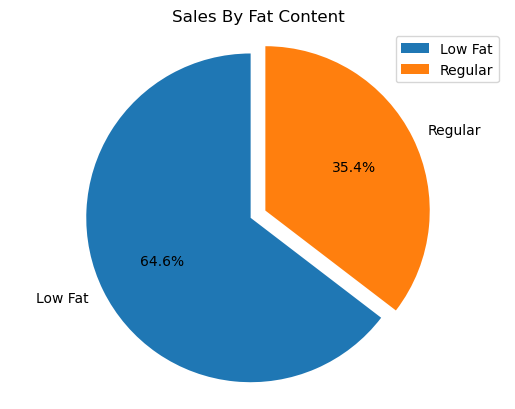

Item Fat Content
Low Fat    776319.6784
Regular    425361.8024
Name: Sales, dtype: float64

In [13]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

# color = ['blue','green']
explode_values = [0.1,0]
plt.pie(sales_by_fat,labels=sales_by_fat.index,autopct='%.1f%%',startangle=90,explode = explode_values)
plt.title('Sales By Fat Content')
plt.axis('equal')
plt.legend()
plt.show()
sales_by_fat

## Total Sales by Item Type

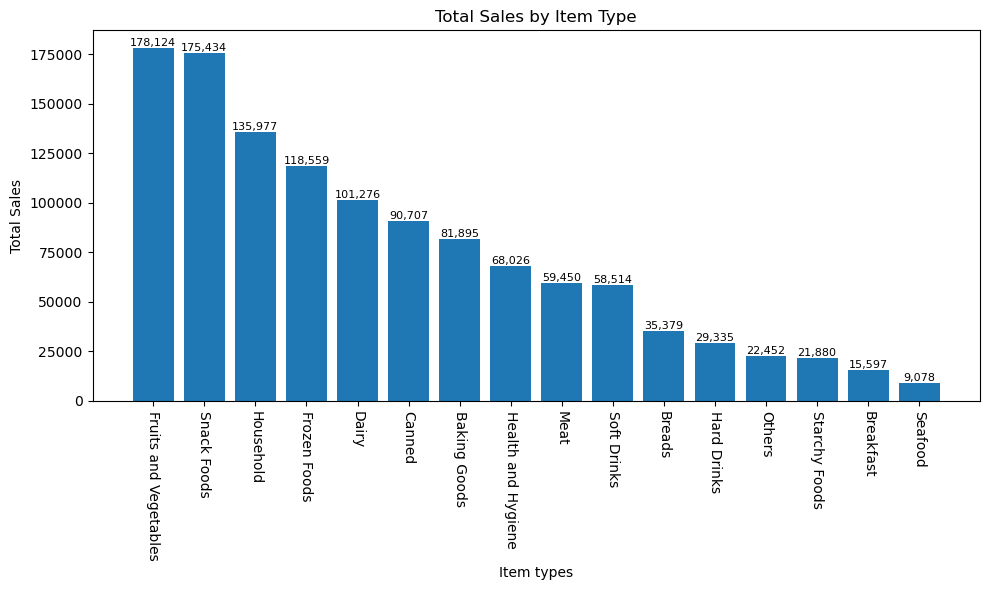

In [14]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_type.index,sales_by_type.values)


plt.xlabel("Item types")
plt.ylabel("Total Sales")
plt.title("Total Sales by Item Type")
plt.xticks(rotation =-90)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha='center',va='bottom',fontsize =8)
plt.tight_layout()
# plt.style.use('dark-background')
plt.show()

## Fat Content by Outlet For total Sales

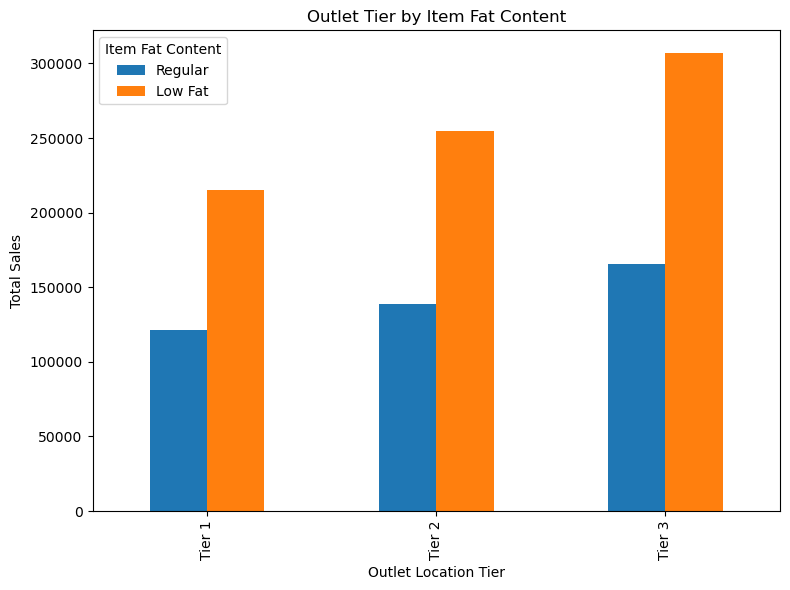

In [15]:
grouped = df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular','Low Fat']]

ax = grouped.plot(kind = 'bar',figsize=(8,6),title ='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel("Total Sales")
plt.legend(title = 'Item Fat Content')
plt.tight_layout()
plt.show()
            

## Total Sales by Outlet Establishment

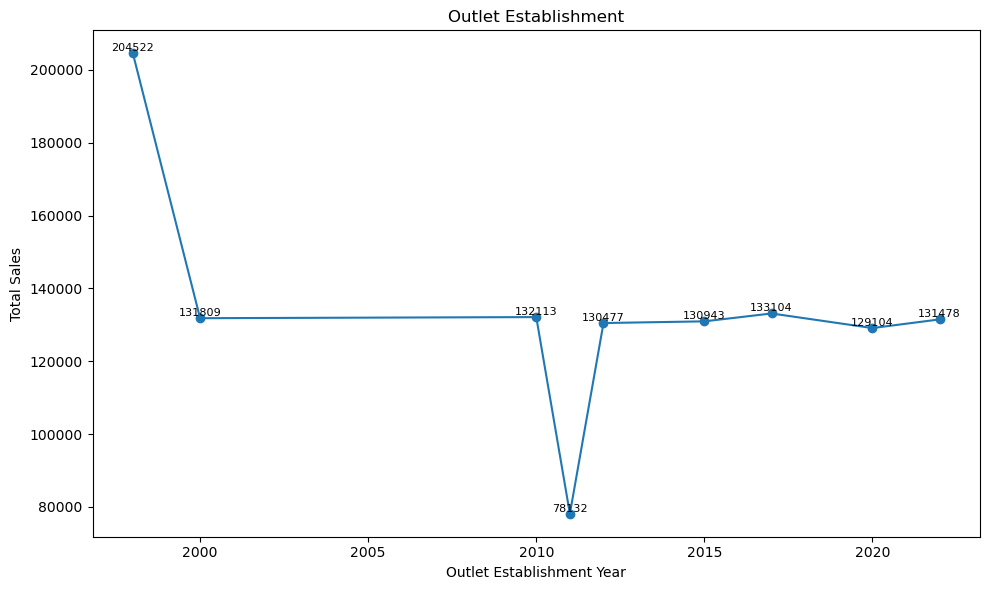

In [16]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(10,6))
plt.plot(sales_by_year.index, sales_by_year.values,marker='o',linestyle = '-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x,y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x,y,f'{y:.0f}',ha='center', va='bottom',fontsize=8)
plt.tight_layout()
plt.show()
    

## Sales By Outlet Size

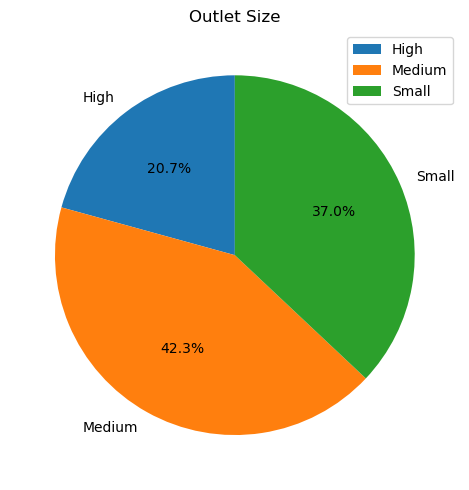

In [17]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()
plt.figure(figsize=(5,5))
plt.pie(sales_by_size,labels=sales_by_size.index,autopct='%.1f%%',startangle=90)
plt.title("Outlet Size")
plt.legend()
plt.tight_layout()
plt.show()

## Sales By Outlet Locations

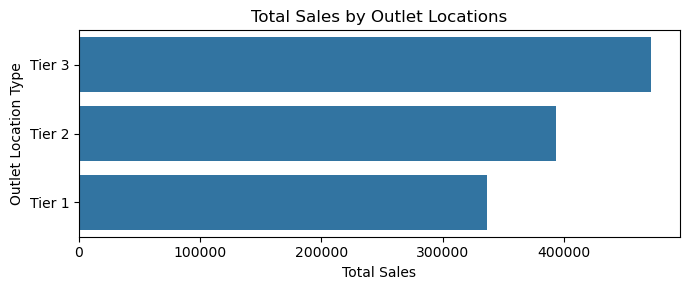

In [18]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Sales',ascending=False)

plt.figure(figsize=(7,3))
ax =sns.barplot(x='Sales',y='Outlet Location Type',data= sales_by_location)

plt.title('Total Sales by Outlet Locations')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout()
plt.show()